# Estimating cosmological parameters and selecting cosmological models with SNIa data

We find best-fit parameters and select the best cosmological model using the [Supernova Cosmology Project](http://supernova.lbl.gov/union/) data. These consist of measurements of the distance modulus of 580 Supernovae Ia, an excellent standard candle:

$$DM = m_B-M_B$$

with $m_B$ apparent magnitude and $M_B$ absolute magnitude in some band (e.g. the blue band, $B$). The absolute magnitude is inferred from the shape of $m_B(t)$. This can be related in turn to the redshift $z$ of the source:

$$DM(z, \boldsymbol{\theta})=5 \log_{10} \dfrac{d_{L}(z, \boldsymbol{\theta})}{\text{Mpc}}+25$$

with $d_L$ luminosity distance of the source. In the *flat* Standard Cosmological model LCDM, this is given by

$$d_{L}\left(z; h_0, \Omega_{m}\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h_0}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})}}$$

with $h_0$ is the dimensionless Hubble constant and $\Omega_{m}$ the density parameter of matter. In this model Dark Energy (DE) is interpreted as a constant term ($\Lambda$) in Einstein's field equations of General Relativity.
A simple generalization of this model is to consider DE as a perfect fluid with equation of state $p=w\rho$, with $w$ the equation of state parameter (wCDM). It reduces to LCDM for $w = -1$ = const. In this model the luminosity distance is

$$d_{L}\left(z; h_0, \Omega_{m}, w\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h_0}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})\left(1+z^{\prime}\right)^{3(1+w)}}}$$

To sum up, we will explore two possibilities

1.  flat LCDM model: $w=-1=\rm{const}$,  $\quad\boldsymbol{\theta}=(h_0, \Omega_{m})$
2.  flat wCDM model: variable $w$, $\quad \boldsymbol{\theta}=(h_0, \Omega_{m}, w)$


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import emcee
from scipy.integrate import quad, dblquad, nquad, tplquad
import pandas as pd
import time
import scipy.optimize
import seaborn as sns
import corner
from scipy.stats import norm
from astropy.cosmology import LambdaCDM
from astropy.cosmology import wCDM
from astropy import units as aq
from astropy.io import ascii
from scipy import stats

params = {
    'lines.linewidth': 2,
    'font.size': 17,
    'axes.labelsize': 'large',
    'axes.titlesize': 'large',
    'xtick.labelsize': 'large',
    'ytick.labelsize': 'large',
}
plt.rcParams.update(params)
import matplotlib.cm as cm

In [23]:
# import data:
root = '/Users/davidesciotti/Documents/Work/Code/Astrostats'
data_union = np.genfromtxt(f'{root}/input/SCPUnion2.1_mu_vs_z.txt')


z_obs = data_union[:, 1]
y_obs = data_union[:, 2]
sigma_y = data_union[:, 3]
N_obs = z_obs.size

which_prior = 'flat'
models = ['LCDM', 'wCDM']

c = 299792.458  # km/s

**Data**: $(z_i, DM_i)$


*   No uncertainties on $x$ axis
*   Uncorrelated measurements (diagonal covariance matrix in $y$)



Text(0, 0.5, 'distance modulus')

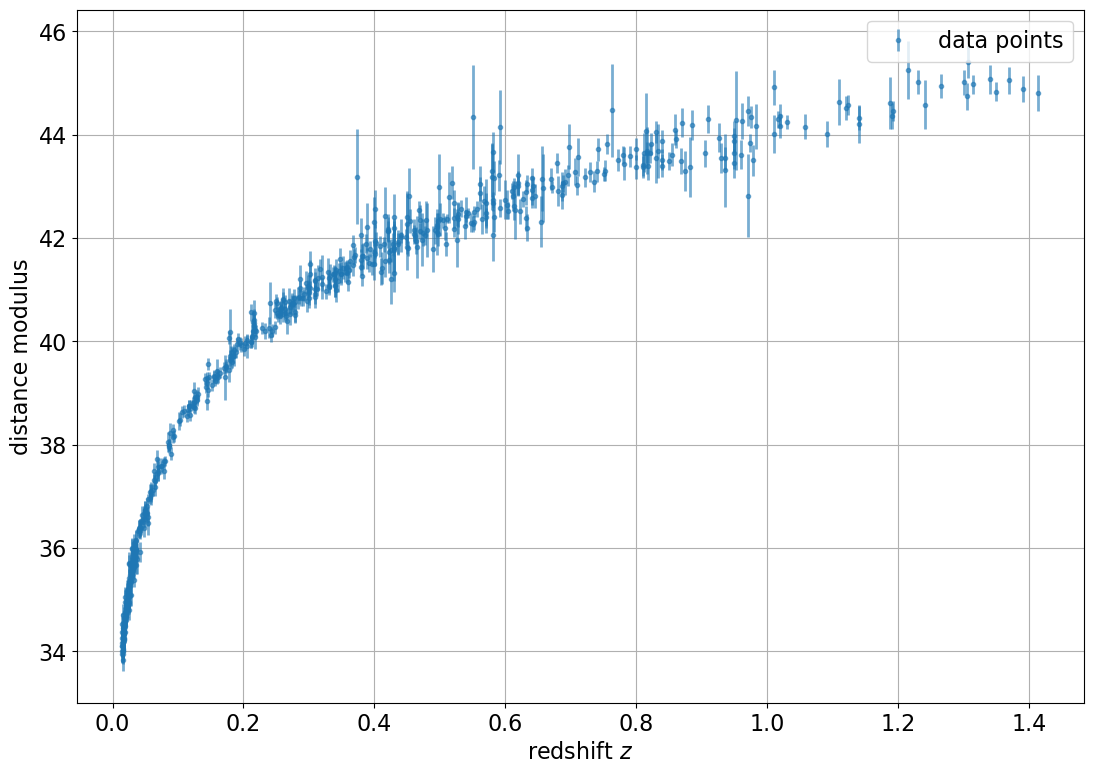

In [ ]:
plt.figure(figsize=(13, 9))
plt.tick_params(labelsize=16)
plt.errorbar(z_obs, y_obs, yerr=sigma_y, fmt='.', alpha=0.6)
plt.grid()
plt.legend(prop={'size': 16})
plt.xlabel('redshift $z$', fontsize=16)
plt.ylabel('$\mu(z)$', fontsize=16)

# Maximum Likelihood Estimation
As a starting point, let's try to estimate the best-fit parameters by maximizing the logarithm of the likelihood LL (the log is a monothonic function, so it doesn't affect the location of the maximum) - or equivalently by minimizing the negative log likelihood, NLL. \
As seen, this has a couple issues:
- it is just a point estimate, and does not take into account the full shape of $\mathcal{L}(\boldsymbol{\theta};\text{data})$
- it does not take into account the prior probabilities $p(\boldsymbol{\theta})$, considering de facto $p(\boldsymbol{\theta}|\text{data})=p(\text{data}|\boldsymbol{\theta})$

We work with a Gaussian Likelihood, describing our error model (we assume the data points to be normally distributed around their predicted values):

$$p(\text{data}|\boldsymbol\theta) = {\cal L}(\boldsymbol\theta ; \text{data}) = \prod_{i=1}^N \dfrac{1}{\sqrt{2\pi}\sigma_i}\exp\left[ -\dfrac{1}{2}\left( \dfrac{y_i-DM (z_i, \boldsymbol{\theta})}{\sigma_i}\right)^2 \right]$$

where $\text{data}=(\boldsymbol{z}, \boldsymbol{y}, \boldsymbol{\sigma})$. The total likelihood is the product of the individual likelihoods $\cal{L}_i$, because we are assuming uncorrelated measurements both on the $x$ and the $y$ axis. $N$ indicates the number of data points (= 580).

We note that, since we're working with diagonal covariance and Gaussian likelihood, maximizing the LL is the same as finding the "least squares fit", i.e. minimizing the quantity

$$\chi^{2}=\sum_{i=1}^{N} \left( \frac{y_{i}-DM\left(z_{i}, \boldsymbol{\theta}\right)}{\sigma_{i}} \right)^{2}.$$



# Define model, priors, likelihood and posterior

In [25]:
def model(z, theta, which_model):
    if which_model == 'LCDM':
        h0, Om = theta
        Ode = 1 - Om
        dl = LambdaCDM(H0=100.0 * h0, Om0=Om, Ode0=Ode).luminosity_distance(z)
    elif which_model == 'wCDM':
        h0, Om, w0 = theta
        Ode = 1 - Om
        dl = wCDM(H0=100.0 * h0, Om0=Om, Ode0=Ode, w0=w0).luminosity_distance(z)
    dm = 5.0 * np.log10(dl.to(aq.Mpc) / (1.0e-5 * aq.Mpc))
    return dm


def ln_prior(theta):
    if which_model == 'LCDM':
        h0, Om = theta
    elif which_model == 'wCDM':
        h0, Om, w0 = theta

    ln_prior_val = 0.0

    ####################### FLAT PRIORS ######################
    if which_prior == 'flat':
        if h0 < 0.3 or h0 > 1.1:
            return -np.inf
        else:
            ln_prior_val += np.log(1 / (2 * 0.8))

        if Om < 0 or Om > 1:
            return -np.inf
        else:
            ln_prior_val += np.log(1)

        if which_model == 'wCDM':
            if w0 < -2 or w0 > 0:
                return -np.inf
            else:
                ln_prior_val += np.log(1 / 2)

    ####################### GAUSSIAN PRIORS ######################
    # from eBoss 2020: https://www.sdss.org/science/cosmology-results-from-eboss/

    elif which_prior == 'gauss':
        mu = exp_values_L[0]
        sigma = 0.003  # h0
        ln_prior_val += (
            np.log(1.0 / (np.sqrt(2 * np.pi) * sigma)) - 0.5 * (h0 - mu) ** 2 / sigma**2
        )

        mu = exp_values_L[1]
        sigma = 0.004  # Om
        if Om <= 0:
            return -np.inf
        else:
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (Om - mu) ** 2 / sigma**2
            )

        if which_model == 'wCDM':
            mu = exp_values_w[0]
            sigma = 0.007  # h0
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (h0 - mu) ** 2 / sigma**2
            )

            mu = exp_values_w[1]
            sigma = 0.006  # Om
            if Om <= 0:
                return -np.inf
            else:
                ln_prior_val += (
                    np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                    - 0.5 * (Om - mu) ** 2 / sigma**2
                )

            mu = exp_values_w[2]
            sigma = 0.02  # Om
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (w0 - mu) ** 2 / sigma**2
            )
    ### end of gaussian priors definition
    return ln_prior_val


def ln_likelihood(theta, data, which_model):

    z_obs, y_obs, sigma_y = data

    if which_model == 'LCDM':
        h0, Om = theta
    elif which_model == 'wCDM':
        h0, Om, w0 = theta

    summand = ((y_obs - model(z_obs, theta, which_model)) / sigma_y) ** 2 + 2 * np.log(
        sigma_y
    )
    return -0.5 * N_obs * np.log(2 * np.pi) - 0.5 * np.sum(summand)


def ln_posterior(theta, data, which_model):
    if np.isinf(
        ln_prior(theta)
    ):  # if I'm outside of allowed prior regions, don't even compute the likelihood
        return -np.inf
        print(theta, 'inf')
    else:
        return ln_likelihood(theta, data, which_model) + ln_prior(theta)


# Find $\theta_{MLE}$
Use minimization routine $\tt {scipy.optimize.minimize}$ to find the minimum of the NLL

In [26]:
# gues starting point to search minimum
h0_guess = 0.70
Om_guess = 0.28
w0_guess = -1.1

for i, which_model in enumerate(models):
    if which_model == 'LCDM':
        theta_guess = [h0_guess, Om_guess]
        bounds = ((0.1, 2), (0.01, 1))
    elif which_model == 'wCDM':
        theta_guess = [h0_guess, Om_guess, w0_guess]
        bounds = ((0.1, 2), (0.01, 1), (-2, 0))

    negative_LL = lambda *args: -ln_likelihood(*args)

    data = z_obs, y_obs, sigma_y
    p0_scipy = scipy.optimize.minimize(
        negative_LL, theta_guess, args=(data, which_model), bounds=bounds
    )['x']

    if which_model == 'LCDM':
        p0_scipy_L = p0_scipy
    elif which_model == 'wCDM':
        p0_scipy_w = p0_scipy

    print(
        f'\nmodel: {which_model}\nBest guess from scipy.optimize: h0, Om, (w0) = {p0_scipy}'
    )



model: LCDM
Best guess from scipy.optimize: h0, Om, (w0) = [0.70002417 0.27761214]

model: wCDM
Best guess from scipy.optimize: h0, Om, (w0) = [ 0.70018352  0.28116438 -1.00988935]


# Perform $\chi^2$ test for goodness of fit
We compute $\chi^2 = \sum_{i=1}^{N} \left( \dfrac{y_i-DM (z_i, \boldsymbol{\theta})}{\sigma_i}\right)^2$, which is a random variable following a a $\chi^2$ distribution with $\nu = N-d$ degrees of freedom (dof); $d$ is the number of parameters of the model.

The measured $\chi^2$ value should be close to $\nu$, indicating that $|y_i-DM (z_i, \boldsymbol{\theta})|$ should be close to $\sigma_i$ $\forall i$. $\chi^2/\nu > 1$ indicates underfitting, whereas $\chi^2/\nu < 1$ indicates overfitting.

chi2
LCDM model, chi2:	 562.23
LCDM model, dof:	 578.00
LCDM model, chi2/dof:	 0.973
LCDM model, pdf(chi2):	 0.011

wCDM model, chi2:	 562.22
wCDM model, dof:	 577.00
wCDM model, chi2/dof:	 0.974
wCDM model, pdf(chi2):	 0.011



<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:68: SyntaxWarning: invalid escape sequence '\c'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:68: SyntaxWarning: invalid escape sequence '\c'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/85718811.py:52: SyntaxWarning: invalid escape sequence '\c'
  label='$\chi^2$ %s' % which_model,
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/85718811.py:64: SyntaxWarning: invalid escape sequence '\c'
  label='$\chi^2$ %s' % which_model,
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/85718811.py:67: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi^2$')
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/85718811.py:68: SyntaxWarning: invalid escape sequenc

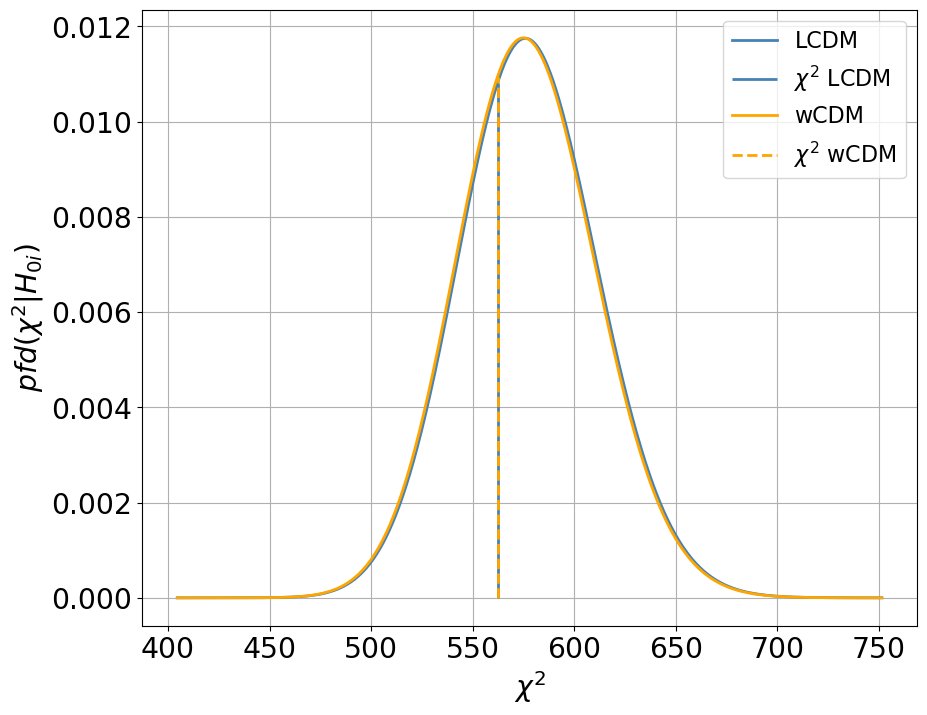

In [ ]:
def compute_chi2(which_model, data=data):
    z_obs, y_obs, sigma_y = data

    if which_model == 'LCDM':
        best_theta = p0_scipy_L
    if which_model == 'wCDM':
        best_theta = p0_scipy_w

    summand = ((y_obs - model(z_obs, best_theta, which_model)) / sigma_y) ** 2
    return np.sum(summand)


def compute_dof(which_model, data=data):
    nparams = 2
    if which_model == 'LCDM':
        nparams = 2
    elif which_model == 'wCDM':
        nparams = 3
    return data[0].shape[0] - nparams


def pdf_chi2(which_model):
    chi2 = compute_chi2(which_model)
    dof = compute_dof(which_model)
    return stats.chi2(dof).pdf(chi2)


print('chi2')
for which_model in ['LCDM', 'wCDM']:
    print(f'{which_model} model, chi2:\t {compute_chi2(which_model):.2f}')
    print(f'{which_model} model, dof:\t {compute_dof(which_model):.2f}')
    print(
        f'{which_model} model, chi2/dof:\t {compute_chi2(which_model) / compute_dof(which_model):.3f}'
    )
    print(f'{which_model} model, pdf(chi2):\t {pdf_chi2(which_model):.3f}')
    print('')


dof = compute_dof('LCDM')
x = np.linspace(dof - 0.3 * dof, dof + 0.3 * dof, 1000)

plt.figure(figsize=(10, 8))
which_model = 'LCDM'
plt.plot(
    x, stats.chi2(compute_dof(which_model)).pdf(x), label=which_model, color='steelblue'
)
plt.vlines(
    compute_chi2(which_model),
    0,
    np.max(stats.chi2(compute_dof(which_model)).pdf(compute_chi2(which_model))),
    color='steelblue',
    label='$\chi^2$ %s' % which_model,
)
which_model = 'wCDM'
plt.plot(
    x, stats.chi2(compute_dof(which_model)).pdf(x), label=which_model, color='orange'
)
plt.vlines(
    compute_chi2(which_model),
    0,
    np.max(stats.chi2(compute_dof(which_model)).pdf(compute_chi2(which_model))),
    color='orange',
    linestyles='dashed',
    label='$\chi^2$ %s' % which_model,
)
plt.legend(prop={'size': 16})
plt.xlabel('$\chi^2$')
plt.ylabel('$p(\chi^2|H_{0i})$')
plt.grid()


# Perform hypothesis test to check whether LCDM or wCDM can be rejected

We perform a p-value test to check the compatibility of the null hypothesis ("the model is true") with the observed data. The p-value is defined as (for a one-sided right-tailed test):
$$p = P(\chi^2 \geq  \chi^2_{obs} | H_0) = \int^{\infty}_{\chi^2_{obs}} \text {pdf}(\chi^2|H_0)\text d \chi^2$$
It is the probability of measuring a more extreme value than the one observed, *if the null hypothesis $H_0$ is true* (which is not the probability that $H_0$ is true!). If this probability is very low, then there is very little chanche that, if H_0 is true, will yeld an equally or more extreme result (read: the data is very unlikely under $H_0$) \
Being $\alpha$ the established threshold for rejecting $H_0$ (usually 0.05, or 5%):
* if $p > \alpha$, $H_0$ is not rejected at $(1-\alpha)$ "confidence"
* if $p < \alpha$, $H_0$ is rejected at $(1-\alpha)$ "confidence"
If the measured p-value is smaller than the established threshold (usually 0.05, or 5%), $H_0$ is rejected at $(1-\alpha)$ "confidence"

In [44]:
integrand = lambda chi2, dof: stats.chi2(dof).pdf(chi2)


def p_value_test(which_model, alpha, direction):
    dof = compute_dof(which_model)
    chi2_measured = compute_chi2(which_model)
    if direction == 'left':
        p_value = quad(integrand, -np.inf, chi2_measured, args=(dof,))[0]
    elif direction == 'right':
        p_value = quad(integrand, chi2_measured, np.inf, args=(dof,))[0]
    return p_value


which_model = 'LCDM'
alpha = 0.05
p_value = p_value_test(which_model, alpha, 'right')
if p_value > alpha:
    print(
        f'p-value = {p_value:.3f} > {alpha} - the null hypothesis (the {which_model} model) cannot be rejected'
    )
which_model = 'wCDM'
p_value = p_value_test(which_model, alpha, 'right')
if p_value > alpha:
    print(
        f'p-value = {p_value:.3f} > {alpha} - the null hypothesis (the {which_model} model) cannot be rejected'
    )


p-value = 0.673 > 0.05 - the null hypothesis (the LCDM model) cannot be rejected
p-value = 0.662 > 0.05 - the null hypothesis (the wCDM model) cannot be rejected


# Perform $\chi^2$-diff test to select between competing models

A possible test to discriminate between the competing models is to check the likelihood ratio, computing $R=\dfrac{{\cal L}_{LCDM}(\text{data}|\hat{\boldsymbol{\theta}}_1)}{ {\cal L}_{wCDM}(\text{data}|\hat{\boldsymbol{\theta}}_2)}$. $\hat{\boldsymbol{\theta}}_i$ refer to the different best-fit parameters of the two models. This quantity is also a random variable following a $\chi^2$ distribution with $\nu_{LCDM}-\nu_{wCDM}$, which in this case equals to 1.

null hypothesis:	 LCDM is the true model
alternative hypothesis:	 wCDM is the true model

p-value = 0.961 > 0.05 - the null hypothesis (LCDM is the true model) cannot be rejected


<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:39: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:39: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/3893938043.py:27: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(x, pdf_chi2, 'steelblue', label='$pdf(\Delta\chi^2)$')
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/3893938043.py:33: SyntaxWarning: invalid escape sequence '\D'
  label='$\Delta\chi^2$ measured',
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/3893938043.py:38: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta\chi^2$')
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/3893938043.py:

Text(0, 0.5, '$pdf(\\Delta\\chi^2)$')

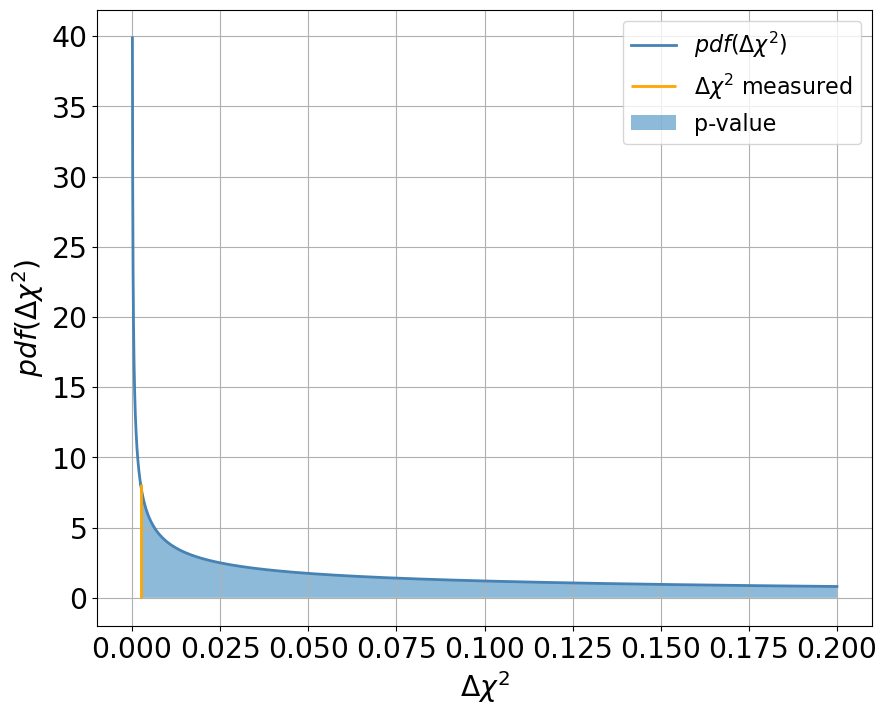

In [29]:
print('null hypothesis:\t LCDM is the true model')
print('alternative hypothesis:\t wCDM is the true model')
print('')

# compute chi2 diff and diff in dofs
chi2_diff = compute_chi2('LCDM') - compute_chi2('wCDM')
dof_diff = compute_dof('LCDM') - compute_dof('wCDM')

# compute p-value
alpha = 0.05
p_value = quad(integrand, chi2_diff, np.inf, args=(dof_diff,))[0]
if p_value > alpha:
    print(
        f'p-value = {p_value:.3f} > {alpha} - the null hypothesis (LCDM is the true model) cannot be rejected'
    )

# plot distribution and p-value
plt.figure(figsize=(10, 8))

x = np.linspace(0.0001, chi2_diff, 1000)
pdf_chi2 = stats.chi2(dof_diff).pdf(x)  # 1 dof
plt.plot(x, pdf_chi2, 'steelblue')


x = np.linspace(chi2_diff, 0.2, 1000)
pdf_chi2 = stats.chi2(dof_diff).pdf(x)
plt.plot(x, pdf_chi2, 'steelblue', label='$pdf(\Delta\chi^2)$')
plt.vlines(
    chi2_diff,
    0,
    stats.chi2(dof_diff).pdf(chi2_diff),
    colors='orange',
    label='$\Delta\chi^2$ measured',
)
plt.fill_between(x, 0, pdf_chi2, alpha=0.5, label='p-value')
plt.grid()
plt.legend(prop={'size': 16})
plt.xlabel('$\Delta\chi^2$')
plt.ylabel('$pdf(\Delta\chi^2)$')


([], [])

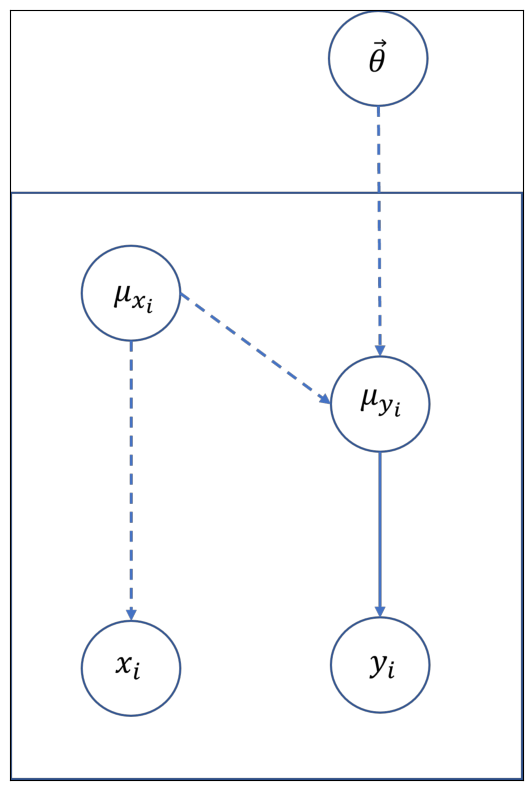

In [31]:
import matplotlib.image as img

plt.subplots(figsize=(10, 10))
# read png image file
im = img.imread(f'{root}/input/Bayesian_network.png')

plt.imshow(im)
plt.xticks([])
plt.yticks([])

# Bayesian approach: constructing and sampling the posterior
Now we turn to a Bayesian approach for parameter estimation and model selection; the posterior distribution of the parameters given the data is given by Bayes' theorem:

$$p(\boldsymbol\theta | \text {data}) = \dfrac{p(\text {data}|\boldsymbol\theta)p(\boldsymbol \theta)}   {p(\text{data})}  $$

This simple relation comes from a number of assumptions in our simplified model;calling for a moment $z_i = x_i$ and $DM_i = y_i$, we have in fact:
- deterministic relation between the measurements $x_i$ and $\mu_{xi}$ : $f(x_i|\mu_{xi}) = \delta(\mu_{xi}-x_i)$
- deterministic relation between $\mu_{yi}$ and $\mu_{xi}, \boldsymbol\theta$ : $f(\mu_{yi}|\mu_{xi}, \boldsymbol\theta) = \delta(\mu_{yi}-\mu_y(\mu_{xi}, \boldsymbol\theta))$
- probabilistic relation only between $y_i$ and $\mu_{yi}$ : $f(y_i|\mu_{yi}) = \cal N (\mu_{yi}, \sigma_{yi}) = \cal N (\mu_y(\mu_{xi}, \boldsymbol\theta), \sigma_{yi})$

In this case this allows us to write

\begin{align*}
p(\boldsymbol\theta | \text {data}) &=& f(\boldsymbol \theta|\boldsymbol x, \boldsymbol y) = \int f(\boldsymbol \theta, \boldsymbol\mu_{x}, \boldsymbol\mu_{y}|\boldsymbol x, \boldsymbol y)\text d \boldsymbol\mu_{x} \text d \boldsymbol\mu_{y}\\
&\propto& \int f(\boldsymbol \theta, \boldsymbol\mu_{x}, \boldsymbol\mu_{y},\boldsymbol x, \boldsymbol y)\text d \boldsymbol\mu_{x} \text d \boldsymbol\mu_{y}\\
&\propto& \int f(\boldsymbol x|\boldsymbol \mu_{x})f(\boldsymbol y| \boldsymbol \mu_{y})f(\boldsymbol \mu_{y}|\boldsymbol \mu_x, \boldsymbol\theta)f(\boldsymbol \mu_x) f(\boldsymbol \theta)\text d \boldsymbol\mu_{x} \text d \boldsymbol\mu_{y} \\
&\propto&  f(\boldsymbol y| \boldsymbol \mu_{y}(\boldsymbol x, \boldsymbol \theta))f(\boldsymbol\theta) = p(\text {data}|\boldsymbol\theta)p(\boldsymbol \theta)
\end{align*}

having used the Dirac deltas to perform the integrals in $\boldsymbol\mu_{x}, \boldsymbol\mu_{y}$


We choose flat and relatively broad priors distribution for the parameters' values, with ranges $[0.3,1.1],[0,1],[-2,0]$  for $(h_0, \Omega_m, w_0)$ respectively, so as to be data-dominated.

We use the $\tt {emcee}$ Python package for the sampling process, with 2000 steps and 10 independent walkers starting from the best-fit values obtained by minimizing the NLL, with a small random deviation from such position for each walker. We discard the initial 10% of the points as burn-in








In [32]:
Nsteps = 2000
Nwalkers = 10
nburn = int(Nsteps / 10)

for which_model in models:
    fraction = 0.1
    if which_model == 'LCDM':
        p0_scipy = p0_scipy_L
        Ndim = p0_scipy.size
        p0 = np.asarray(
            [
                p0_scipy
                + [
                    np.random.uniform(-fraction * p0_scipy[0], fraction * p0_scipy[0]),
                    np.random.uniform(-fraction * p0_scipy[1], fraction * p0_scipy[1]),
                ]
                for i in range(Nwalkers)
            ]
        )
    elif which_model == 'wCDM':
        p0_scipy = p0_scipy_w
        Ndim = p0_scipy.size
        p0 = np.asarray(
            [
                p0_scipy
                + [
                    np.random.uniform(-fraction * p0_scipy[0], fraction * p0_scipy[0]),
                    np.random.uniform(-fraction * p0_scipy[1], fraction * p0_scipy[1]),
                    np.random.uniform(-fraction * p0_scipy[2], fraction * p0_scipy[2]),
                ]
                for i in range(Nwalkers)
            ]
        )

    sampler = emcee.EnsembleSampler(
        Nwalkers, Ndim, ln_posterior, args=(data, which_model)
    )
    pos, prob, state = sampler.run_mcmc(p0, Nsteps, progress=True)

    if which_model == 'LCDM':
        trace_L = sampler.chain[:, nburn:, :].reshape(-1, Ndim)
        labels = ['$h_0$', '$\Omega_m$']
        labels_noTeX = ['h0', 'Om']
    elif which_model == 'wCDM':
        trace_w = sampler.chain[:, nburn:, :].reshape(-1, Ndim)
        labels = ['$h_0$', '$\Omega_m$', '$w_0$']
        labels_noTeX = ['h0', 'Om', 'w0']

<>:42: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\O'
<>:42: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\O'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/822119976.py:42: SyntaxWarning: invalid escape sequence '\O'
  labels = ['$h_0$', '$\Omega_m$']
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/822119976.py:46: SyntaxWarning: invalid escape sequence '\O'
  labels = ['$h_0$', '$\Omega_m$', '$w_0$']
100%|██████████| 2000/2000 [02:17<00:00, 14.51it/s]


**Save traces**

In [33]:
np.save(f'{root}/output/trace_LCDM_steps_{Nsteps}_walkers_{Nwalkers}.npy', trace_L)
np.save(f'{root}/output/trace_wCDM_steps_{Nsteps}_walkers_{Nwalkers}.npy', trace_w)

#Compute expected values, variances and probabilities


--------------------- LCDM -------------------------------------

h0: 0.700 +/- 0.003 at P = 0.68
Om: 0.28 +/- 0.02 at P = 0.68

parameters' covariance matrix:
[[ 1.15940520e-05 -4.83674076e-05]
 [-4.83674076e-05  3.71714866e-04]]

parameters' correlation matrix:
[[ 1.00012502 -0.73679868]
 [-0.73679868  0.99996072]]


--------------------- wCDM -------------------------------------

h0: 0.700 +/- 0.005 at P = 0.67
Om: 0.27 +/- 0.08 at P = 0.67
w0: -1.0 +/- 0.2 at P = 0.67

parameters' covariance matrix:
[[ 2.17098015e-05  1.92532380e-04 -6.52617504e-04]
 [ 1.92532380e-04  6.39457894e-03 -1.52922635e-02]
 [-6.52617504e-04 -1.52922635e-02  4.18978736e-02]]

parameters' correlation matrix:
[[ 0.9999912   0.51674957 -0.68430474]
 [ 0.51674957  1.00005601 -0.93432641]
 [-0.68430474 -0.93432641  1.00007671]]



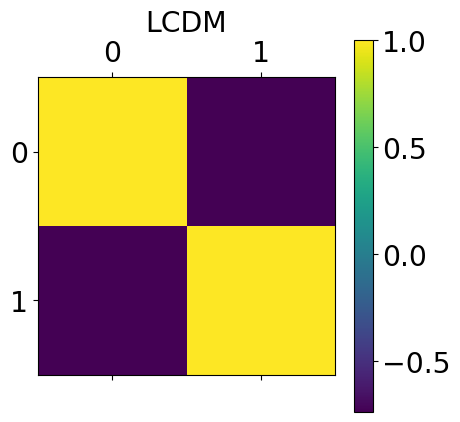

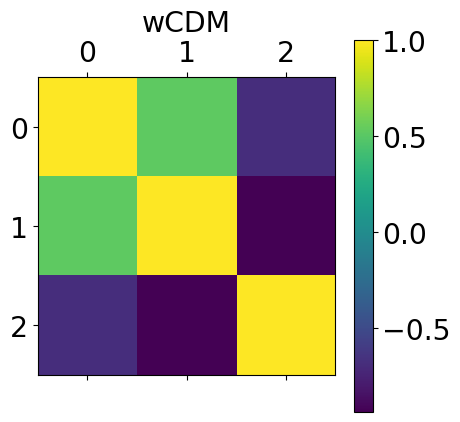

In [34]:
def Exp(x, fx):
    return np.sum(x * fx) / np.sum(fx)


def Variance(x, fx):
    E = Exp(x, fx)
    return np.sum((x - E) ** 2 * fx) / np.sum(fx)


def get_prob(x, fx, low, high):
    low_index = np.digitize(low, bins)
    high_index = np.digitize(high, bins)
    return np.sum(fx[low_index:high_index]) / np.sum(fx)


for which_model in models:
    if which_model == 'LCDM':
        trace = trace_L
        Ndim = p0_scipy_L.size
    elif which_model == 'wCDM':
        trace = trace_w
        Ndim = p0_scipy_w.size

    exp_values = []
    sigmas = []
    probs = []

    print(
        f'\n--------------------- {which_model} -------------------------------------\n'
    )
    for param_index in range(Ndim):  # 0 for h0, 1 for Om, 2 for Ode
        fx_obs, bins = np.histogram(trace[:, param_index], bins=500, density=False)
        x_obs = (bins[1:] + bins[:-1]) / 2

        E = Exp(x_obs, fx_obs)
        Var = Variance(x_obs, fx_obs)
        sigma = np.sqrt(Var)
        prob = get_prob(x_obs, fx_obs, E - sigma, E + sigma)

        exp_values.append(E)
        sigmas.append(sigma)
        probs.append(prob)

    # compute parameter's covariance
    cov = np.cov(
        trace.T, bias=True
    )  # each row is a variable, each column an observation

    print(
        f'{labels_noTeX[0]}: {exp_values[0]:.3f} +/- {sigmas[0]:.3f} at P = {prob:.2f}'
    )
    print(
        f'{labels_noTeX[1]}: {exp_values[1]:.2f} +/- {sigmas[1]:.2f} at P = {prob:.2f}'
    )
    if which_model == 'wCDM':
        print(
            f'{labels_noTeX[2]}: {exp_values[2]:.1f} +/- {sigmas[2]:.1f} at P = {prob:.2f}'
        )

    print("\nparameters' covariance matrix:")
    print(cov)

    corr = np.zeros(cov.shape)
    for i in range(cov.shape[0]):
        for j in range(cov.shape[0]):
            corr[i, j] = cov[i, j] / (sigmas[i] * sigmas[j])

    print("\nparameters' correlation matrix:")
    print(corr)

    print('')

    plt.matshow(corr)
    plt.title(which_model)
    plt.colorbar()

    if which_model == 'LCDM':
        exp_values_L = exp_values
        sigmas_L = sigmas
        probs_L = probs
        cov_L = cov

    elif which_model == 'wCDM':
        exp_values_w = exp_values
        sigmas_w = sigmas
        probs_w = probs
        cov_w = cov


# Corner plot

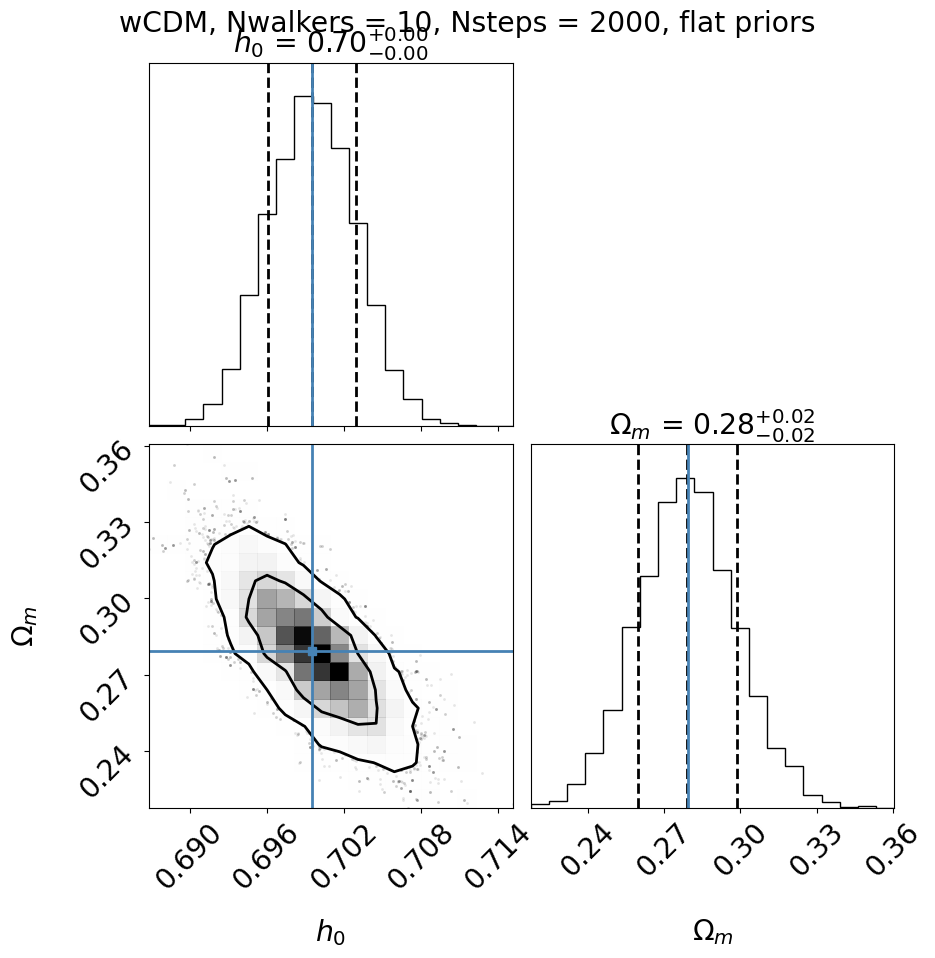

In [35]:
fig = corner.corner(
    trace_L,
    quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
    labels=labels,
    truths=exp_values_L,
    plot_contours=True,
    # fill_contours=True,
    levels=(0.68, 0.95),
    show_titles=True,
)
fig.suptitle(
    f'{which_model}, Nwalkers = {Nwalkers}, Nsteps = {Nsteps}, {which_prior} priors'
)
fig.set_size_inches(10, 10)

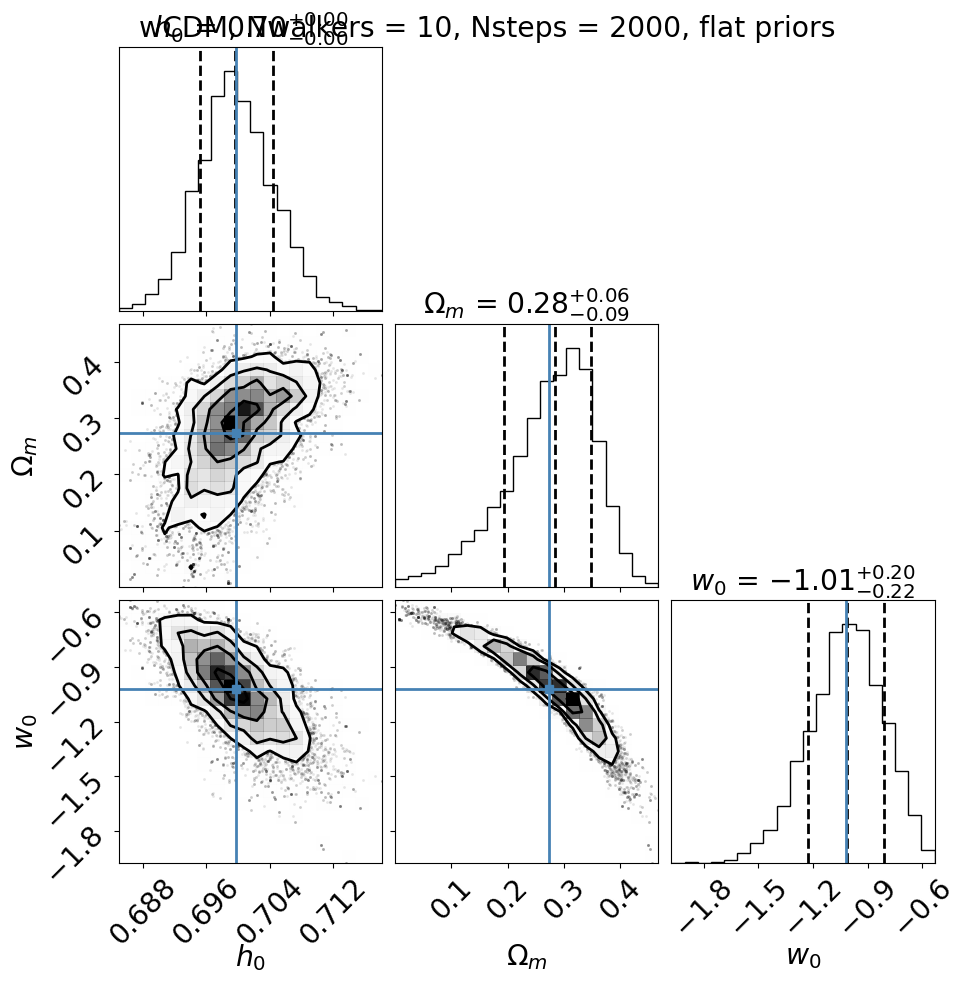

In [36]:
fig = corner.corner(
    trace_w,
    quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
    labels=labels,
    truths=exp_values_w,
    plot_contours=True,
    # fill_contours=True,
    # levels=(0.68, 0.95),
    show_titles=True,
)
fig.suptitle(
    f'{which_model}, Nwalkers = {Nwalkers}, Nsteps = {Nsteps}, {which_prior} priors'
)
fig.set_size_inches(10, 10)

# Trace plot

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/3986204956.py:7: SyntaxWarning: invalid escape sequence '\s'
  axes[0].hlines(exp_values_L[0]+sigmas_L[0], 0, trace_L.shape[0], linestyles="dashed", color = "orange", zorder=2, label = "Exp +/- 1$\sigma$", linewidth=3)
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/3986204956.py:15: SyntaxWarning: invalid escape sequence '\O'
  axes[1].set_ylabel("$\Omega_m$")
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/3986204956.py:17: SyntaxWarning: invalid escape sequence '\s'
  axes[1].hlines(exp_values_L[1]+sigmas_L[1], 0, trace_L.shape[0], linestyles="dashed", color = "orange", zorder=2, label =

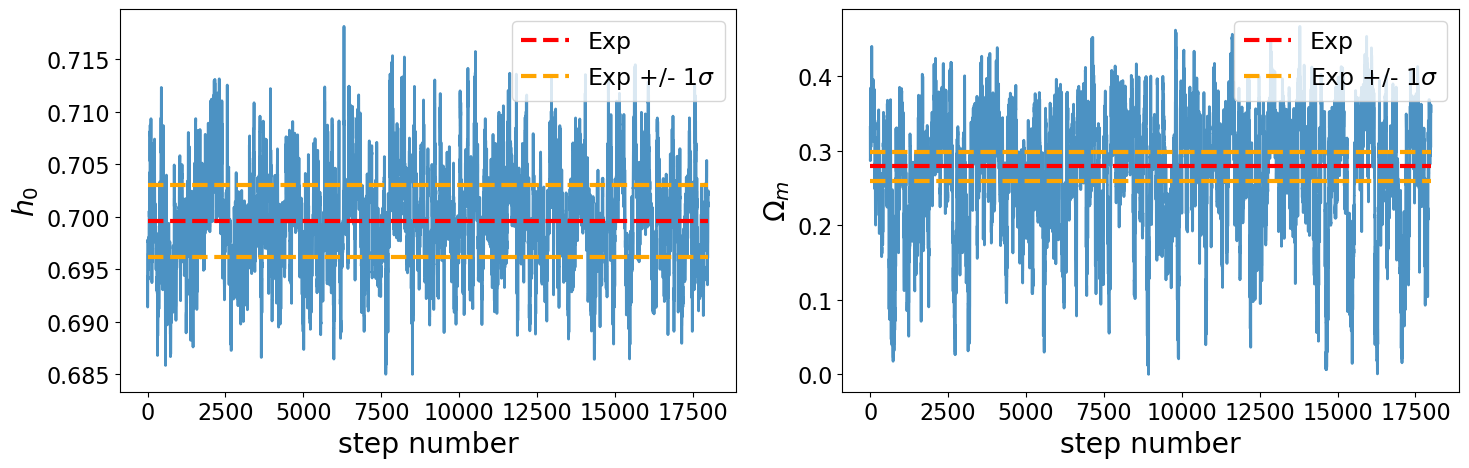

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axes[0].plot(range(trace_L.shape[0]), trace[:,0], zorder=1, alpha = 0.8)
axes[0].set_xlabel("step number")
axes[0].set_ylabel("$h_0$")
axes[0].hlines(exp_values_L[0], 0, trace_L.shape[0], linestyles="dashed", color = "red", zorder=2, label = "Exp", linewidth=3)
axes[0].hlines(exp_values_L[0]+sigmas_L[0], 0, trace_L.shape[0], linestyles="dashed", color = "orange", zorder=2, label = "Exp +/- 1$\sigma$", linewidth=3)
axes[0].hlines(exp_values_L[0]-sigmas_L[0], 0, trace_L.shape[0], linestyles="dashed", color = "orange", zorder=2, linewidth=3)
axes[0].legend(loc = "upper right")
axes[0].tick_params(labelsize=16)


axes[1].plot(range(trace_L.shape[0]), trace[:,1], zorder=1, alpha = 0.8)
axes[1].set_xlabel("step number")
axes[1].set_ylabel("$\Omega_m$")
axes[1].hlines(exp_values_L[1], 0, trace_L.shape[0], linestyles="dashed", color = "red", zorder=2, label = "Exp", linewidth=3)
axes[1].hlines(exp_values_L[1]+sigmas_L[1], 0, trace_L.shape[0], linestyles="dashed", color = "orange", zorder=2, label = "Exp +/- 1$\sigma$", linewidth=3)
axes[1].hlines(exp_values_L[1]-sigmas_L[1], 0, trace_L.shape[0], linestyles="dashed", color = "orange", zorder=2, linewidth=3)
axes[1].legend(loc = "upper right")
axes[1].tick_params(labelsize=16)

fig.tight_layout()

# Plot best-fit curves and residuals
No appreciable difference between the two models, plot just LCDM. This simply to visually inspect the bes-fit line and to check whether the residuals show any unwanted trend.

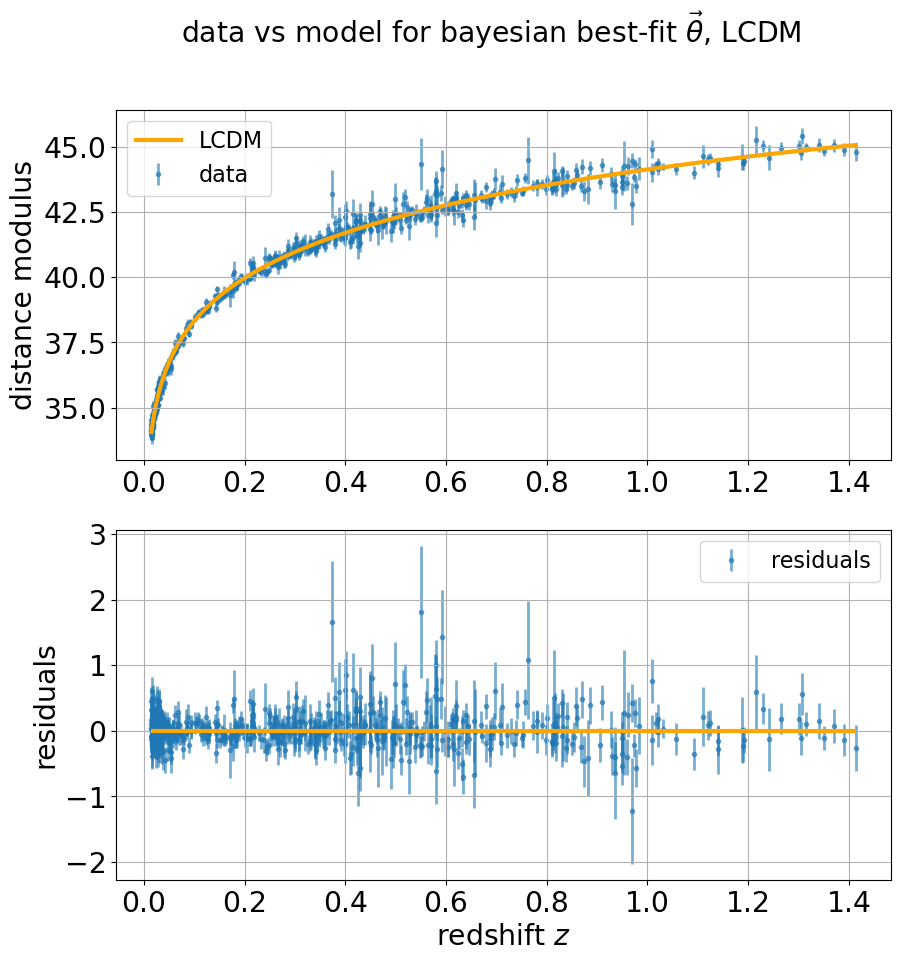

In [38]:
which_model = 'LCDM'

if which_model == 'LCDM':
    theta_best_fit = exp_values_L
elif which_model == 'wCDM':
    theta_best_fit = exp_values_w

# sort the data
data_union = data_union[np.argsort(data_union[:, 1])]
z_obs = data_union[:, 1]
y_obs = data_union[:, 2]
sigma_y = data_union[:, 3]

fig, axs = plt.subplots(2)
fig.suptitle('data vs model for bayesian best-fit $\\vec{\\theta}$, %s' % which_model)
fig.set_size_inches(10, 10)

axs[0].errorbar(z_obs, y_obs, yerr=sigma_y, fmt='.', alpha=0.6, label='data', zorder=1)
axs[0].plot(
    z_obs,
    model(z_obs, theta_best_fit, which_model),
    label=which_model,
    color='orange',
    linewidth=3,
    zorder=1.5,
)
axs[0].set_ylabel('distance modulus')
axs[0].grid()
axs[0].legend(prop={'size': 16})

axs[1].errorbar(
    z_obs,
    y_obs - model(z_obs, theta_best_fit, which_model),
    yerr=sigma_y,
    fmt='.',
    label='residuals',
    alpha=0.6,
    zorder=1,
)
axs[1].hlines(0, z_obs.min(), z_obs.max(), color='orange', zorder=2, linewidth=3)
axs[1].set_ylabel('residuals')
axs[1].set_xlabel('redshift $z$')
axs[1].grid()
axs[1].legend(prop={'size': 16})

# Bayesian model selection
In order to select the best model we compute the odds ratio

$$O_{12} = \dfrac{p(M_1|\text{data})}{p(M_2|\text{data})}=\dfrac{p(\text{data}|M_1)P(M_1)}{p(\text{data}|M_2)P(M_2)}=\dfrac{\int p(\text{data}|M_1,\boldsymbol\theta_1)p(\boldsymbol\theta_1|M_1)\text{d}\boldsymbol\theta_1}{\int p(\text{data}|M_2,\boldsymbol\theta_2)p(\boldsymbol\theta_2|M_2)\text{d}\boldsymbol\theta_2}\dfrac{p(M_1)}{p(M_2)}$$

which is simply the ratio of the posterior distributions, marginalized over the parameters of the models, folded with the prior probabilities on the different models (which we consider equal to each other).


Models with more parameters will be penalized with respect to models with fewer parameters, because the larger the number of parameters the more spread the prior will have with respect to the likelihood.


Already in 3-dimensional parameter space (for model wCDM) the computation takes a very long time. We therefore implement a routine to integrate the function with a simple random sampling of the posterior over the prior domain, exploiting the relation

$$\int f (\boldsymbol x) \text d \boldsymbol x \simeq \prod_{i=1}^d (b_i-a_i)\langle f(\boldsymbol x) \rangle =  \dfrac{\prod_{i=1}^d (b_i-a_i)}{N} \sum_{i=1}^N f(\boldsymbol x_i)$$

with $N$ number of sampling points, $d$ the number of dimensions of $\boldsymbol x$, and $(a_i, b_i)$ lower and upper bounds of the different priors' domains. The $x_i$ are, in our case, drawn from a uniform pdf.

1.2487889259760203e-05
6.513956979822958e-05
0.19170972879375095
170.66666666666669
0.34712781413978966
2.4174855227566256 200


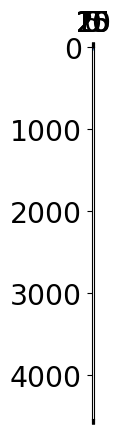

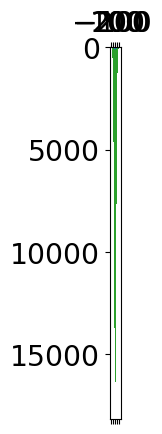

In [39]:
"""
def mc_integrate_3D(func, ranges, n = 10000):

    low_h0, high_h0, low_Om, high_Om, low_w0, high_w0 = ranges

    h0_list = np.random.uniform(low_h0, high_h0, n)
    Om_list = np.random.uniform(low_Om, high_Om, n)
    w0_list = np.random.uniform(low_w0, high_w0, n)

    y = np.asarray([func(h0_list[i], Om_list[i], w0_list[i]) for i in range(n)])

    y_mean =  (y.sum())/len(y)
    domain = (high_h0-low_h0)*(high_Om-low_Om)*(high_w0-low_w0)

    integral = domain * y_mean
    return integral


h0_lim = (0.3, 1.1)
Om_lim = (0,1)
w0_lim = (-2,0)


start = time.time()
which_model = "LCDM"
ranges = (h0_lim, Om_lim)
integrand = lambda h0, Om: np.exp(ln_posterior([h0, Om], data, which_model))
Z_L = nquad(integrand, ranges) # integrate with nquad
print(f"Z_L = {Z_L[0]:.3e}, {which_model}, {time.time() - start:.1f} seconds to compute the integral")


start = time.time()
which_model = "wCDM"
ranges = np.asarray((h0_lim, Om_lim, w0_lim)).reshape(6).tolist()
integrand = lambda h0, Om, w0: np.exp(ln_posterior([h0, Om, w0], data, which_model))
Z_w_MC = mc_integrate_3D(integrand, ranges, n = 10000)  # integrate with MC

# ranges = (h0_lim, Om_lim, w0_lim)
# Z_w_nquad = nquad(integrand, ranges)  # integrate with nquad - very slow

Z_w = Z_w_MC
print(f"Z_w = {Z_w:.3e}, {which_model}, {time.time() - start:.1f} seconds to compute the integral")

O12 = Z_L[0]/Z_w
print(f"O12 = {O12:.3f} > 1, LCDM is the preferred model")
if (1 < O12 <= 3): print("strenght of evidence in facour of LCDM: barely worth mentioning")
elif (3 < O12 <= 10): print("substantial support for LCDM")

print('\ncomputation using scipy nquad:')
Z_w = 3.319218472708639063e+47
O12 = Z_L[0]/Z_w
print(f"O12 = {O12:.3f} > 1, LCDM is the preferred model")
if (1 < O12 <= 3): print("strenght of evidence in facour of LCDM: barely worth mentioning")
elif (3 < O12 <= 10): print("substantial support for LCDM")
"""

################### INTEGRATE THE POSTERIOR RAMPLED FROM MCMC ("trace")
nbins = 20

p1_index = 0
p2_index = 1
p3_index = 2

trace = trace_L
fxy, p1_bin_edges, p2_bin_edges = np.histogram2d(
    trace[:, p1_index], trace[:, p2_index], bins=18
)
plt.matshow(fxy)

delta_p1 = p1_bin_edges[1:] - p1_bin_edges[:-1]
delta_p2 = p2_bin_edges[1:] - p2_bin_edges[:-1]
integral_L = np.sum(delta_p1 * delta_p2 * fxy) / np.sum(fxy)
print(integral_L)

trace = trace_w
fxyz, edges = np.histogramdd(
    (trace[:, p1_index], trace[:, p2_index], trace[:, p3_index]), bins=7
)
edges = np.asarray((edges))
delta_p1 = edges[0, 1:] - edges[0, :-1]
delta_p2 = edges[1, 1:] - edges[1, :-1]
delta_p3 = edges[2, 1:] - edges[2, :-1]

integral_w = np.sum(delta_p1 * delta_p2 * delta_p3 * fxyz) / np.sum(fxyz)
print(integral_w)

print(integral_L / integral_w)


prova = lambda x, y: x**2 + y**2
ranges = ((0, 4), (0, 4))
integral = nquad(prova, ranges)
print(integral[0])

marginal_x = lambda x: (x**2) / 4 + 64 / 3
marginal_y = lambda y: (y**2) / 4 + 64 / 3

N = 10000
x_rand = np.random.uniform(-1, 5, N)
y_rand = np.random.uniform(-1, 5, N)
sampled_marginal_x = marginal_x(x_rand)
sampled_marginal_y = marginal_y(y_rand)
sampled_function = prova(x_rand, y_rand)

t = np.linspace(-1, 5, 1000)
plt.plot(t, marginal_x(t))
plt.hist(sampled_marginal_x)

fxy, p1_bin_edges, p2_bin_edges = np.histogram2d(
    trace[:, p1_index], trace[:, p2_index], nbins
)
plt.matshow(fxy)

plt.plot(np.sort(x_rand), marginal_x(np.sort(x_rand)))
np.sort(x_rand)
marginal_x(np.sort(x_rand))

fx, p1_bin_edges, _ = plt.hist(sampled_marginal_x)
delta_p1 = p1_bin_edges[1:] - p1_bin_edges[:-1]
integral = np.sum(delta_p1 * fx) / np.sum(fxy)
print(integral)

N = 900000
nbins = 200
x = np.random.normal(0, 50, N)
fx, bins, _ = plt.hist(x, bins=nbins)
area = sum(np.diff(bins) * fx) / sum(fx)
print(area, nbins)

# Gaussian priors
We adopt narrow gaussian prior distribution to check how the result change with more restrictive prior knowledge

In [40]:
# Gaussian priors

which_prior = 'gauss'

for which_model in models:
    fraction = 0.1
    if which_model == 'LCDM':
        p0_scipy = p0_scipy_L
        Ndim = p0_scipy.size
        p0 = np.asarray(
            [
                p0_scipy
                + [
                    np.random.uniform(-fraction * p0_scipy[0], fraction * p0_scipy[0]),
                    np.random.uniform(-fraction * p0_scipy[1], fraction * p0_scipy[1]),
                ]
                for i in range(Nwalkers)
            ]
        )
    elif which_model == 'wCDM':
        p0_scipy = p0_scipy_w
        Ndim = p0_scipy.size
        p0 = np.asarray(
            [
                p0_scipy
                + [
                    np.random.uniform(-fraction * p0_scipy[0], fraction * p0_scipy[0]),
                    np.random.uniform(-fraction * p0_scipy[1], fraction * p0_scipy[1]),
                    np.random.uniform(-fraction * p0_scipy[2], fraction * p0_scipy[2]),
                ]
                for i in range(Nwalkers)
            ]
        )

    sampler = emcee.EnsembleSampler(
        Nwalkers, Ndim, ln_posterior, args=(data, which_model)
    )
    pos, prob, state = sampler.run_mcmc(p0, Nsteps, progress=True)

    if which_model == 'LCDM':
        trace_L = sampler.chain[:, nburn:, :].reshape(-1, Ndim)
        labels = ['$h_0$', '$\Omega_m$']
        labels_noTeX = ['h0', 'Om']
    elif which_model == 'wCDM':
        trace_w = sampler.chain[:, nburn:, :].reshape(-1, Ndim)
        labels = ['$h_0$', '$\Omega_m$', '$w_0$']
        labels_noTeX = ['h0', 'Om', 'w0']


<>:42: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\O'
<>:42: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\O'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/1572414046.py:42: SyntaxWarning: invalid escape sequence '\O'
  labels = ['$h_0$', '$\Omega_m$']
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_88911/1572414046.py:46: SyntaxWarning: invalid escape sequence '\O'
  labels = ['$h_0$', '$\Omega_m$', '$w_0$']
100%|██████████| 2000/2000 [02:21<00:00, 14.13it/s]


#Compute expected values, variances and probabilities


--------------------- LCDM -------------------------------------

h0: 0.700 +/- 0.002 at P = 0.68
Om: 0.279 +/- 0.004 at P = 0.68

Gaussian priors:
h0: mu = 0.700; sigma = 0.0036
Om: mu = 0.279; sigma = 0.0047

parameters' covariance matrix:
[[ 3.26191950e-06 -1.16992075e-06]
 [-1.16992075e-06  1.66004809e-05]]

parameters' correlation matrix:
[[ 0.9998426  -0.15898793]
 [-0.15898793  1.00017889]]


--------------------- wCDM -------------------------------------

h0: 0.700 +/- 0.002 at P = 0.69
Om: 0.278 +/- 0.003 at P = 0.69
w0: -1.02 +/- 0.02 at P = 0.69

Gaussian priors:
h0: mu = 0.700; sigma = 0.0073
Om: mu = 0.278; sigma = 0.0066
w: mu = -1.016; sigma = 0.027

parameters' covariance matrix:
[[ 3.58107435e-06 -8.03115270e-07 -8.95591853e-06]
 [-8.03115270e-07  1.07721861e-05 -6.33717519e-06]
 [-8.95591853e-06 -6.33717519e-06  3.05564844e-04]]

parameters' correlation matrix:
[[ 0.99996598 -0.12929921 -0.27073963]
 [-0.12929921  0.99992617 -0.11045452]
 [-0.27073963 -0.11045452  1

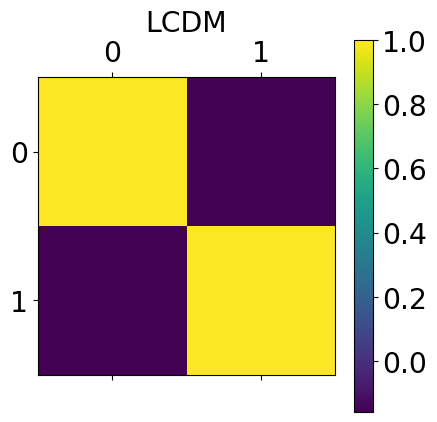

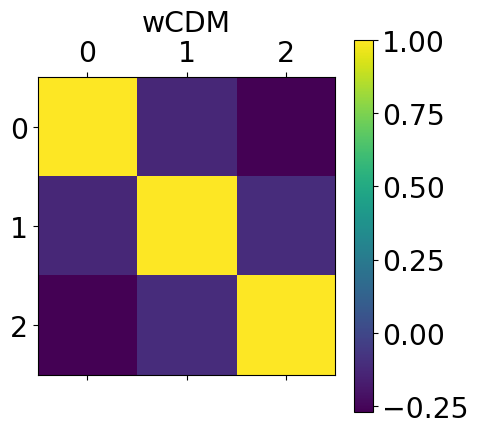

In [41]:
def Exp(x, fx):
    return np.sum(x * fx) / np.sum(fx)


def Variance(x, fx):
    E = Exp(x, fx)
    return np.sum((x - E) ** 2 * fx) / np.sum(fx)  # method 1


def get_prob(x, fx, low, high):
    low_index = np.digitize(low, bins)
    high_index = np.digitize(high, bins)
    return np.sum(fx[low_index:high_index]) / np.sum(fx)


for which_model in models:
    if which_model == 'LCDM':
        trace = trace_L
        Ndim = p0_scipy_L.size
    elif which_model == 'wCDM':
        trace = trace_w
        Ndim = p0_scipy_w.size

    exp_values = []
    sigmas = []
    probs = []

    print(
        f'\n--------------------- {which_model} -------------------------------------\n'
    )
    for param_index in range(Ndim):  # 0 for h0, 1 for Om, 2 for Ode
        fx_obs, bins = np.histogram(trace[:, param_index], bins=500, density=False)
        x_obs = (bins[1:] + bins[:-1]) / 2

        E = Exp(x_obs, fx_obs)
        Var = Variance(x_obs, fx_obs)
        sigma = np.sqrt(Var)
        prob = get_prob(x_obs, fx_obs, E - sigma, E + sigma)

        exp_values.append(E)
        sigmas.append(sigma)
        probs.append(prob)

    # compute parameter's covariance
    cov = np.cov(
        trace.T, bias=True
    )  # each row is a variable, each column an observation

    print(
        f'{labels_noTeX[0]}: {exp_values[0]:.3f} +/- {sigmas[0]:.3f} at P = {prob:.2f}'
    )
    print(
        f'{labels_noTeX[1]}: {exp_values[1]:.3f} +/- {sigmas[1]:.3f} at P = {prob:.2f}'
    )
    if which_model == 'wCDM':
        print(
            f'{labels_noTeX[2]}: {exp_values[2]:.2f} +/- {sigmas[2]:.2f} at P = {prob:.2f}'
        )

    corr = np.zeros(cov.shape)
    for i in range(cov.shape[0]):
        for j in range(cov.shape[0]):
            corr[i, j] = cov[i, j] / (sigmas[i] * sigmas[j])

    plt.matshow(corr)
    plt.title(which_model)
    plt.colorbar()

    if which_model == 'LCDM':
        exp_values_L = exp_values
        sigmas_L = sigmas
        probs_L = probs
        cov_L = cov
        print('\nGaussian priors:')
        print(f'h0: mu = {exp_values_L[0]:.3f}; sigma = 0.0036')
        print(f'Om: mu = {exp_values_L[1]:.3f}; sigma = 0.0047')

    elif which_model == 'wCDM':
        exp_values_w = exp_values
        sigmas_w = sigmas
        probs_w = probs
        cov_w = cov
        print('\nGaussian priors:')
        print(f'h0: mu = {exp_values_w[0]:.3f}; sigma = 0.0073')
        print(f'Om: mu = {exp_values_w[1]:.3f}; sigma = 0.0066')
        print(f'w: mu = {exp_values_w[2]:.3f}; sigma = 0.027')

    print("\nparameters' covariance matrix:")
    print(cov)
    print("\nparameters' correlation matrix:")
    print(corr)
    print('')

# Corner plot

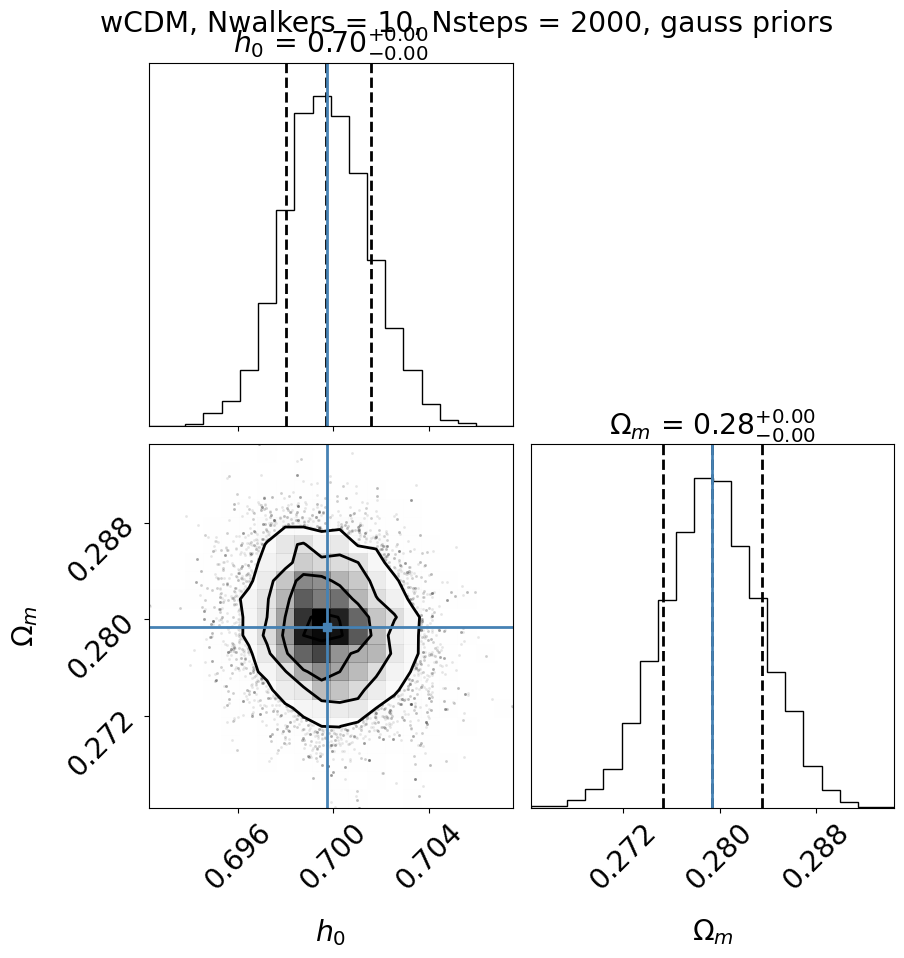

In [42]:
fig = corner.corner(
    trace_L,
    quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
    labels=labels,
    truths=exp_values_L,
    plot_contours=True,
    # fill_contours=True,
    # levels=(0.68, 0.95),
    show_titles=True,
)
fig.suptitle(
    f'{which_model}, Nwalkers = {Nwalkers}, Nsteps = {Nsteps}, {which_prior} priors'
)
fig.set_size_inches(10, 10)

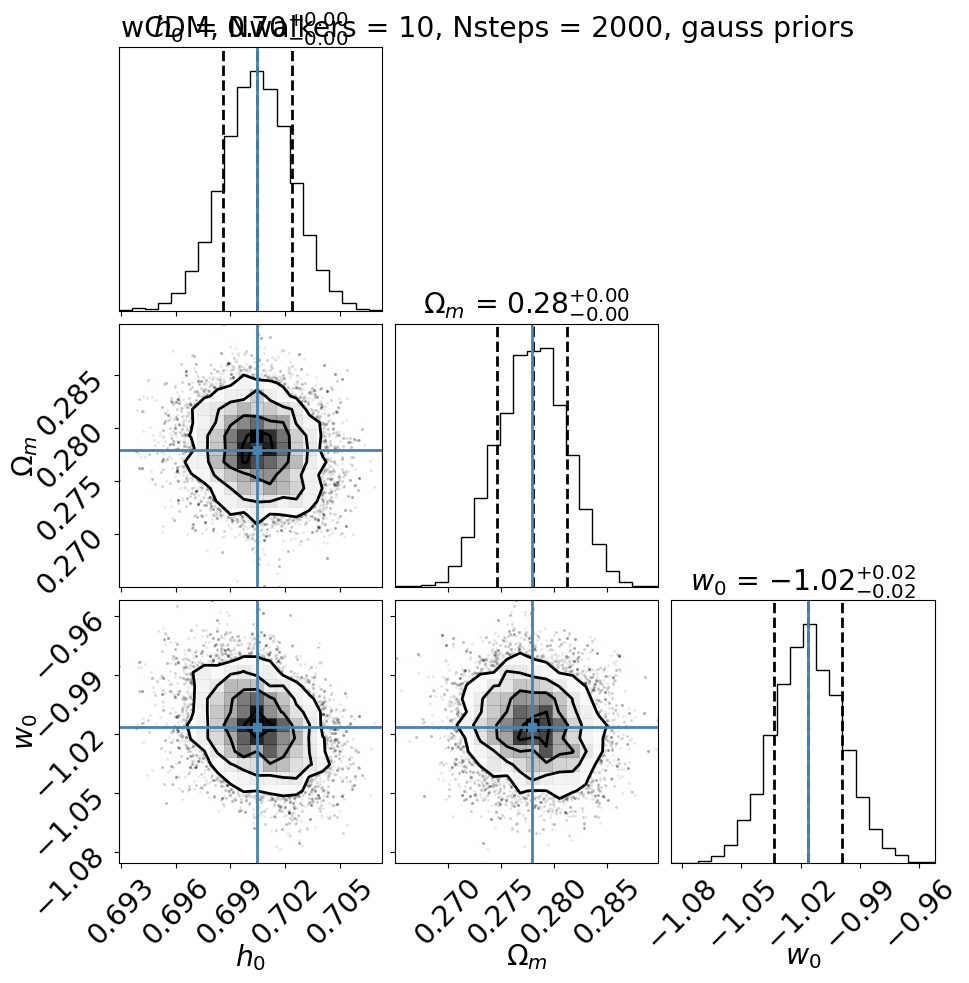

In [43]:
fig = corner.corner(
    trace_w,
    quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
    labels=labels,
    truths=exp_values_w,
    plot_contours=True,
    # fill_contours=True,
    # levels=(0.68, 0.95),
    show_titles=True,
)
fig.suptitle(
    f'{which_model}, Nwalkers = {Nwalkers}, Nsteps = {Nsteps}, {which_prior} priors'
)
fig.set_size_inches(10, 10)